# Electricity Consumption Forecasting
## Exploratory Data Analysis

**Dataset:** Spanish electricity grid data (2015–2018)  
**Source:** ENTSOE Transparency Platform + OpenWeatherMap  
**Target:** `total load actual` — hourly electricity demand (MW)

---

### Contents
1. Setup & Imports  
2. Data Loading  
3. Data Quality Assessment  
4. Target Variable Overview  
5. Seasonal Patterns  
6. Generation Mix  
7. Price Analysis  
8. Weather Features  
9. Correlation Analysis  
10. Time Series Decomposition  
11. ACF / PACF Analysis

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

DATA_DIR = "data/archive/"
print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Data Loading

In [2]:
# Load energy dataset
energy = pd.read_csv(DATA_DIR + "energy_dataset.csv", parse_dates=["time"])
energy["time"] = pd.to_datetime(energy["time"], utc=True)
energy = energy.set_index("time").sort_index()

# Load weather dataset
weather = pd.read_csv(DATA_DIR + "weather_features.csv", parse_dates=["dt_iso"])
weather["dt_iso"] = pd.to_datetime(weather["dt_iso"], utc=True)
weather = weather.sort_values("dt_iso")

print(f"Energy dataset:  {energy.shape[0]:,} rows × {energy.shape[1]} columns")
print(f"  Date range:    {energy.index.min()} → {energy.index.max()}")
print()
print(f"Weather dataset: {weather.shape[0]:,} rows × {weather.shape[1]} columns")
print(f"  Cities:        {sorted(weather['city_name'].str.strip().unique().tolist())}")
energy.head(3)

Energy dataset:  35,064 rows × 28 columns
  Date range:    2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00

Weather dataset: 178,396 rows × 17 columns
  Cities:        ['Barcelona', 'Bilbao', 'Madrid', 'Seville', 'Valencia']


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48


In [3]:
weather.head(3)

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2014-12-31 23:00:00+00:00,Valencia,270.475000,270.475000,270.475000,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
35145,2014-12-31 23:00:00+00:00,Madrid,267.325000,267.325000,267.325000,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
71412,2014-12-31 23:00:00+00:00,Bilbao,269.657312,269.657312,269.657312,1036,97,0,226,0.0,0.0,0.0,0,800,clear,sky is clear,01


## 3. Data Quality Assessment

### 3.1 Missing values

In [3]:
missing = energy.isna().sum()
missing_pct = (energy.isna().mean() * 100).round(2)
missing_df = pd.DataFrame({"missing count": missing, "missing %": missing_pct})
missing_df = missing_df[missing_df["missing count"] > 0].sort_values("missing %", ascending=False)
print(f"Columns with missing values: {len(missing_df)}/{energy.shape[1]}")
missing_df

Columns with missing values: 23/28


,missing count,missing %
generation hydro pumped storage aggregated,35064,100.00
forecast wind offshore eday ahead,35064,100.00
total load actual,36,0.10
generation fossil gas,18,0.05
generation biomass,19,0.05
generation fossil brown coal/lignite,18,0.05
generation fossil coal-derived gas,18,0.05
generation fossil oil shale,18,0.05
generation fossil oil,19,0.05
generation fossil hard coal,18,0.05


In [4]:
# Drop columns with no data — they carry zero information
all_null_cols = missing_df[missing_df["missing %"] == 100].index.tolist()
print(f"Dropping {len(all_null_cols)} fully-empty column(s):")
for c in all_null_cols:
    print(f"  • {c}")

energy = energy.drop(columns=all_null_cols)
print(f"\nEnergy shape after drop: {energy.shape}")


Dropping 2 fully-empty column(s):
  • generation hydro pumped storage aggregated
  • forecast wind offshore eday ahead

Energy shape after drop: (35064, 26)


Unique timestamps with ≥1 NaN : 47

How many columns are missing at each affected timestamp:
                # timestamps
# cols missing              
1                         29
20                         6
21                        12


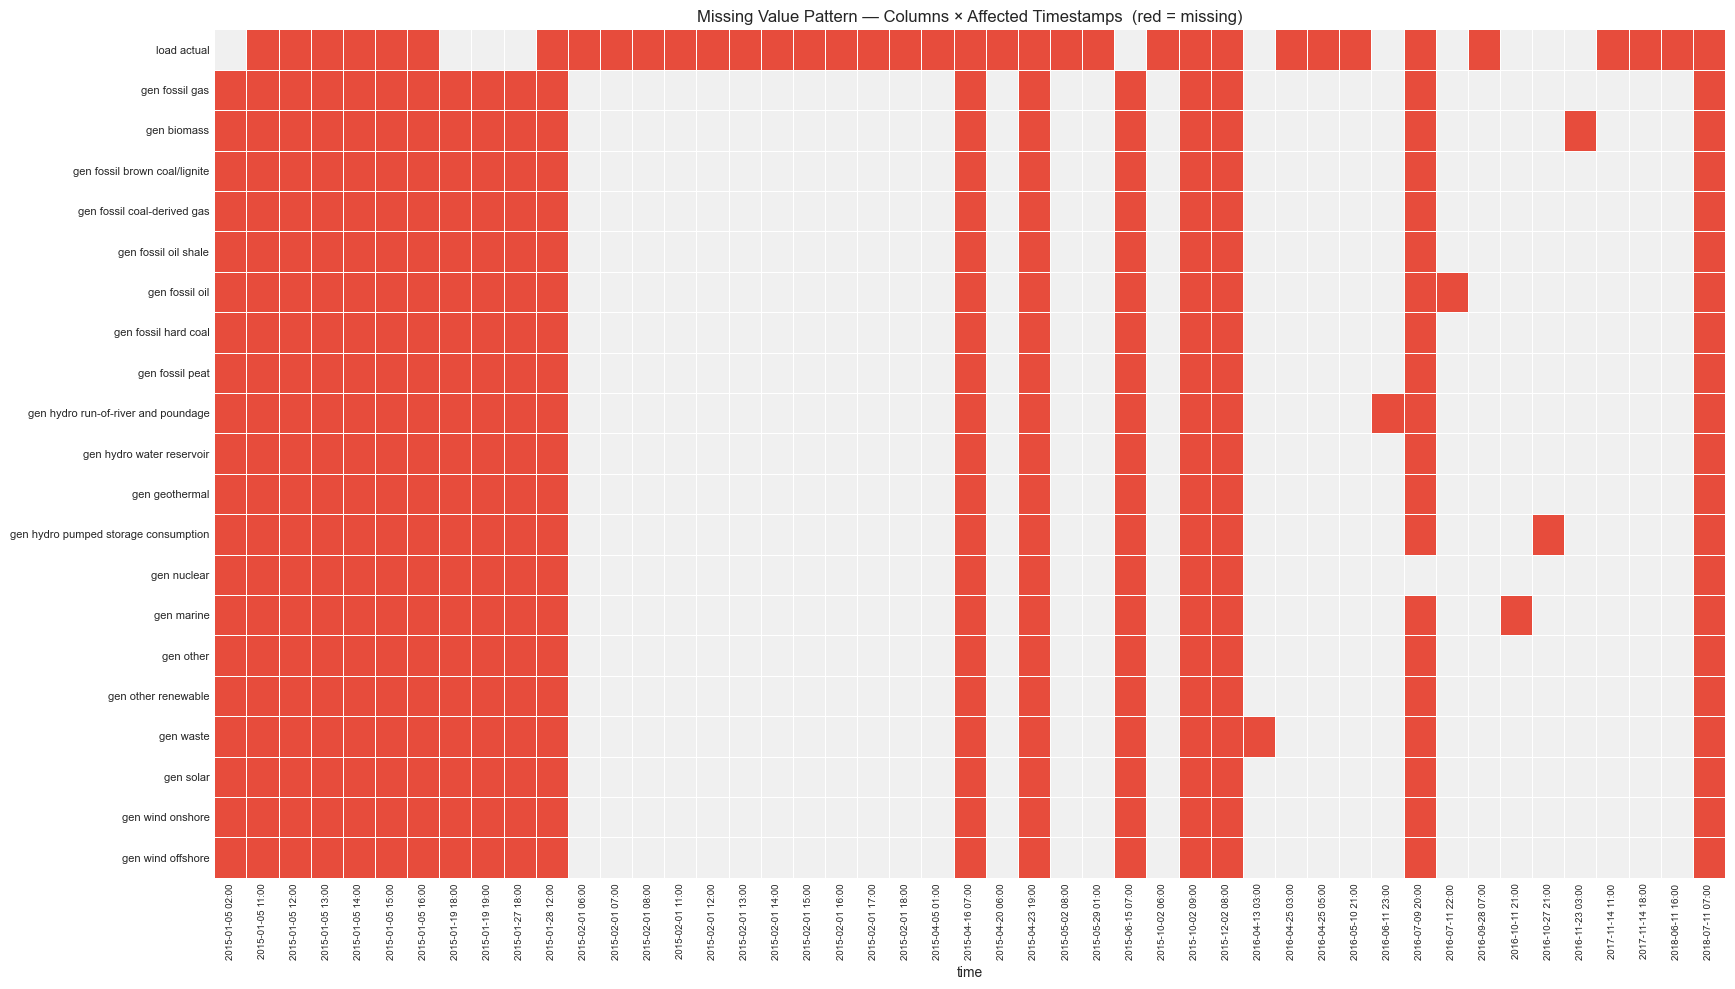

In [6]:
# Are the remaining missing values coincident (same timestamps) or scattered across different columns?
partial_null_cols = missing_df[missing_df["missing %"] < 100].index.tolist()
null_mask = energy[partial_null_cols].isna()
affected = null_mask[null_mask.any(axis=1)]

print(f"Unique timestamps with ≥1 NaN : {len(affected)}")
print()
print("How many columns are missing at each affected timestamp:")
print(
    affected.sum(axis=1)
    .value_counts()
    .sort_index()
    .rename_axis("# cols missing")
    .rename("# timestamps")
    .to_frame()
)

short_labels = [
    c.replace("generation ", "gen ")
     .replace("total load ", "load ")
     .replace("forecast ", "fcst ")
    for c in affected.columns
]

fig, ax = plt.subplots(figsize=(max(6, len(affected) * 0.35 + 1), 10))
sns.heatmap(
    affected.astype(int).T,
    cmap=["#f0f0f0", "#e74c3c"],
    cbar=False,
    linewidths=0.4,
    ax=ax,
    xticklabels=affected.index.strftime("%Y-%m-%d %H:%M"),
    yticklabels=short_labels,
)
ax.set_title("Missing Value Pattern — Columns × Affected Timestamps  (red = missing)", fontsize=12)
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()


### 3.2 Time index completeness

In [5]:
complete_range = pd.date_range(start=energy.index.min(), end=energy.index.max(), freq="h", tz="UTC")
is_complete = len(complete_range) == len(energy.index)

print(f"Expected hourly steps : {len(complete_range):,}")
print(f"Actual rows           : {len(energy.index):,}")
print(f"Missing timestamps    : {len(complete_range) - len(energy.index)}")
print(f"Index complete        : {is_complete}")

dupes = energy.index.duplicated().sum()
print(f"Duplicated timestamps : {dupes}")

Expected hourly steps : 35,064
Actual rows           : 35,064
Missing timestamps    : 0
Index complete        : True
Duplicated timestamps : 0


### 3.3 Missing value imputation for target variable

Before blindly interpolating, we test two structured hypotheses on the **non-missing** rows, then pick the best-performing approach:

| Candidate | Rationale |
|---|---|
| **`total load forecast`** | Day-ahead grid operator forecast — always available, same units |
| **Sum of generation columns** | Energy-balance identity: load ≈ Σ generation |
| **Time interpolation** *(baseline)* | Linear in time; simulated on 50 randomly held-out timestamps |

**Results & conclusion:**  
The energy-balance hypothesis — that total load equals the sum of individual generation sources — does **not** hold in this dataset (R² = 0.69, MAE ≈ 2,000 MW). This is expected: the dataset captures only the sources reported to ENTSO-E and excludes net imports/exports, transmission losses, and behind-the-meter generation, so the sum systematically under-counts actual demand.

`total load forecast` is the right fill-in instead. It is the official day-ahead estimate produced by Red Eléctrica de España using the same methodology and data as the actuals, so it tracks the true load almost perfectly (R² = 0.990, MAE ≈ 316 MW — roughly the size of a single large power plant). The 36 missing actuals represent only 0.1 % of the series; replacing them with the forecast introduces negligible noise and preserves the statistical properties of the target variable far better than either the gen-sum or a naive linear interpolation.


Imputation candidate comparison (evaluated on non-missing rows)
Method                                 R²     MAE (MW)    RMSE (MW)
────────────────────────────────────────────────────────────────────
A  total load forecast             0.9903        316.1        452.6
B  sum of generation cols          0.6899       1995.8       2576.5
C  time interpolation (sim)        0.9813        426.6        567.2

  (C evaluated on 50-point simulated holdout; A & B on full non-missing series)


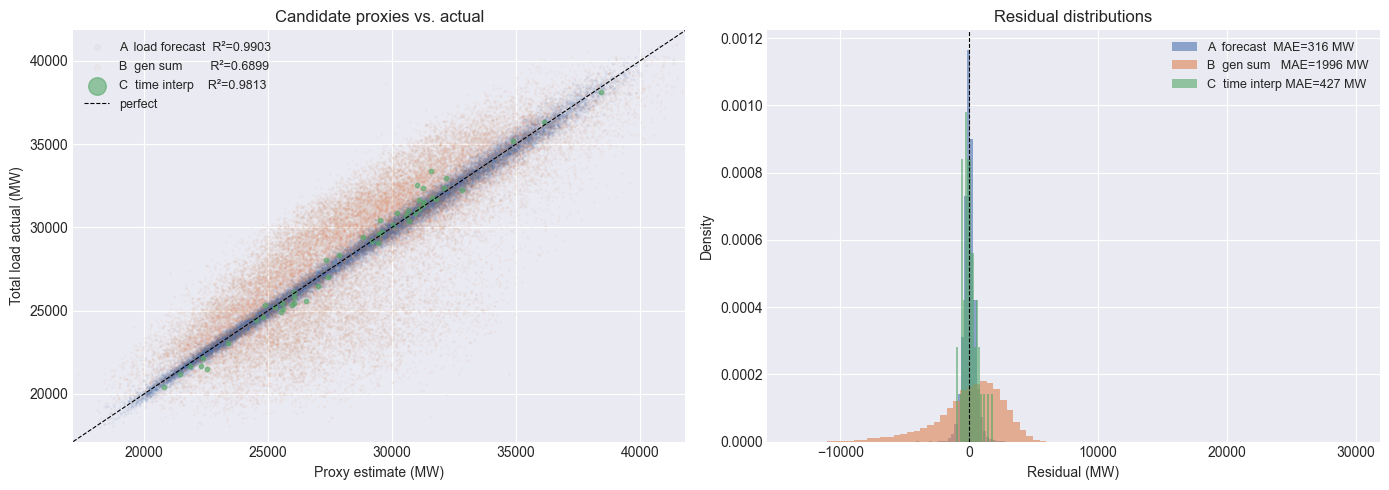

In [9]:
# ── Imputation candidate evaluation ──────────────────────────────────────────
# Work on the energy dataframe that has had the two fully-null columns dropped.
# Evaluate each candidate on rows where total load actual is NOT missing.

gen_cols_imp = [
    c for c in energy.columns
    if c.startswith("generation") and "pumped storage aggregated" not in c
]

# Rows complete for total load actual
complete = energy.dropna(subset=["total load actual"])

# ── Candidate A: total load forecast ─────────────────────────────────────────
resid_A = complete["total load actual"] - complete["total load forecast"]
mae_A   = resid_A.abs().mean()
rmse_A  = np.sqrt((resid_A**2).mean())
r2_A    = complete["total load actual"].corr(complete["total load forecast"]) ** 2

# ── Candidate B: sum of generation columns ────────────────────────────────────
complete_gen = complete.dropna(subset=gen_cols_imp)
gen_sum      = complete_gen[gen_cols_imp].sum(axis=1)
resid_B      = complete_gen["total load actual"] - gen_sum
mae_B        = resid_B.abs().mean()
rmse_B       = np.sqrt((resid_B**2).mean())
r2_B         = complete_gen["total load actual"].corr(gen_sum) ** 2

# ── Candidate C: time interpolation (simulated holdout) ──────────────────────
# R² is computed on the 50 holdout points (actual vs interpolated).
# Note: C has no "proxy column" across the full series — it only produces
# an estimate where gaps exist, so evaluation must be done via simulation.
rng       = np.random.default_rng(42)
holdout   = rng.choice(complete.index[10:-10], size=50, replace=False)
ts_masked = complete["total load actual"].copy()
ts_masked.loc[holdout] = np.nan
ts_filled = ts_masked.interpolate(method="time")
y_true_C  = complete.loc[holdout, "total load actual"]
y_pred_C  = ts_filled.loc[holdout]
resid_C   = y_true_C - y_pred_C
mae_C     = resid_C.abs().mean()
rmse_C    = np.sqrt((resid_C**2).mean())
ss_res    = (resid_C**2).sum()
ss_tot    = ((y_true_C - y_true_C.mean())**2).sum()
r2_C      = 1 - ss_res / ss_tot

# ── Summary table ─────────────────────────────────────────────────────────────
print("Imputation candidate comparison (evaluated on non-missing rows)")
print(f"{'Method':<32} {'R²':>8} {'MAE (MW)':>12} {'RMSE (MW)':>12}")
print("─" * 68)
print(f"{'A  total load forecast':<32} {r2_A:>8.4f} {mae_A:>12.1f} {rmse_A:>12.1f}")
print(f"{'B  sum of generation cols':<32} {r2_B:>8.4f} {mae_B:>12.1f} {rmse_B:>12.1f}")
print(f"{'C  time interpolation (sim)':<32} {r2_C:>8.4f} {mae_C:>12.1f} {rmse_C:>12.1f}")
print(f"\n  (C evaluated on {len(holdout)}-point simulated holdout; A & B on full non-missing series)")

# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: proxy vs actual
lim = [complete["total load actual"].min() * 0.95,
       complete["total load actual"].max() * 1.02]
axes[0].scatter(complete["total load forecast"], complete["total load actual"],
                alpha=0.04, s=1, color="#4c72b0",
                label=f"A  load forecast  R²={r2_A:.4f}")
axes[0].scatter(gen_sum, complete_gen["total load actual"],
                alpha=0.04, s=1, color="#dd8452",
                label=f"B  gen sum        R²={r2_B:.4f}")
axes[0].scatter(y_pred_C, y_true_C,
                alpha=0.6, s=10, color="#55a868",
                label=f"C  time interp    R²={r2_C:.4f}")
axes[0].plot(lim, lim, "k--", linewidth=0.8, label="perfect")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("Proxy estimate (MW)")
axes[0].set_ylabel("Total load actual (MW)")
axes[0].set_title("Candidate proxies vs. actual")
axes[0].legend(markerscale=4, fontsize=9)

# Residual distributions
axes[1].hist(resid_A, bins=80, alpha=0.6, color="#4c72b0",
             label=f"A  forecast  MAE={mae_A:.0f} MW", density=True)
axes[1].hist(resid_B, bins=80, alpha=0.6, color="#dd8452",
             label=f"B  gen sum   MAE={mae_B:.0f} MW", density=True)
axes[1].hist(resid_C, bins=20, alpha=0.6, color="#55a868",
             label=f"C  time interp MAE={mae_C:.0f} MW", density=True)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Residual (MW)")
axes[1].set_ylabel("Density")
axes[1].set_title("Residual distributions")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


In [8]:
# Work on a clean copy going forward.
# Use the candidate with the lowest MAE from the evaluation above.
# Ranking is determined at runtime so this cell adapts automatically.
df = energy.copy()

scores = {"total load forecast": mae_A, "gen sum": mae_B, "time interp": mae_C}
winner = min(scores, key=scores.get)
print(f"Winner: {winner}  (MAE A={mae_A:.0f}  B={mae_B:.0f}  C={mae_C:.0f} MW)")

null_mask = df["total load actual"].isna()

if winner in ("total load forecast", "time interp"):
    # Forecast-based: fill NaNs directly from total load forecast
    df.loc[null_mask, "total load actual"] = df.loc[null_mask, "total load forecast"]
else:
    # Gen-sum-based: fill only where gen cols are also complete
    gen_sum_full = df[gen_cols_imp].sum(axis=1)
    gen_complete = df[gen_cols_imp].notna().all(axis=1)
    df.loc[null_mask & gen_complete, "total load actual"] = gen_sum_full[null_mask & gen_complete]

# Fallback: any remaining NaNs (e.g. block outages where forecast is also missing)
remaining = df["total load actual"].isna().sum()
if remaining:
    df["total load actual"] = df["total load actual"].interpolate(method="time")
    print(f"  → {remaining} gap(s) fell back to time interpolation")

print(f"Remaining NaNs in target: {df['total load actual'].isna().sum()}")


Winner: total load forecast  (MAE A=316  B=1996  C=427 MW)
Remaining NaNs in target: 0


## 4. Target Variable: Total Load Actual

`total load actual` is the total electricity demand on the Spanish grid in MW, measured hourly. This is the variable we ultimately want to forecast.

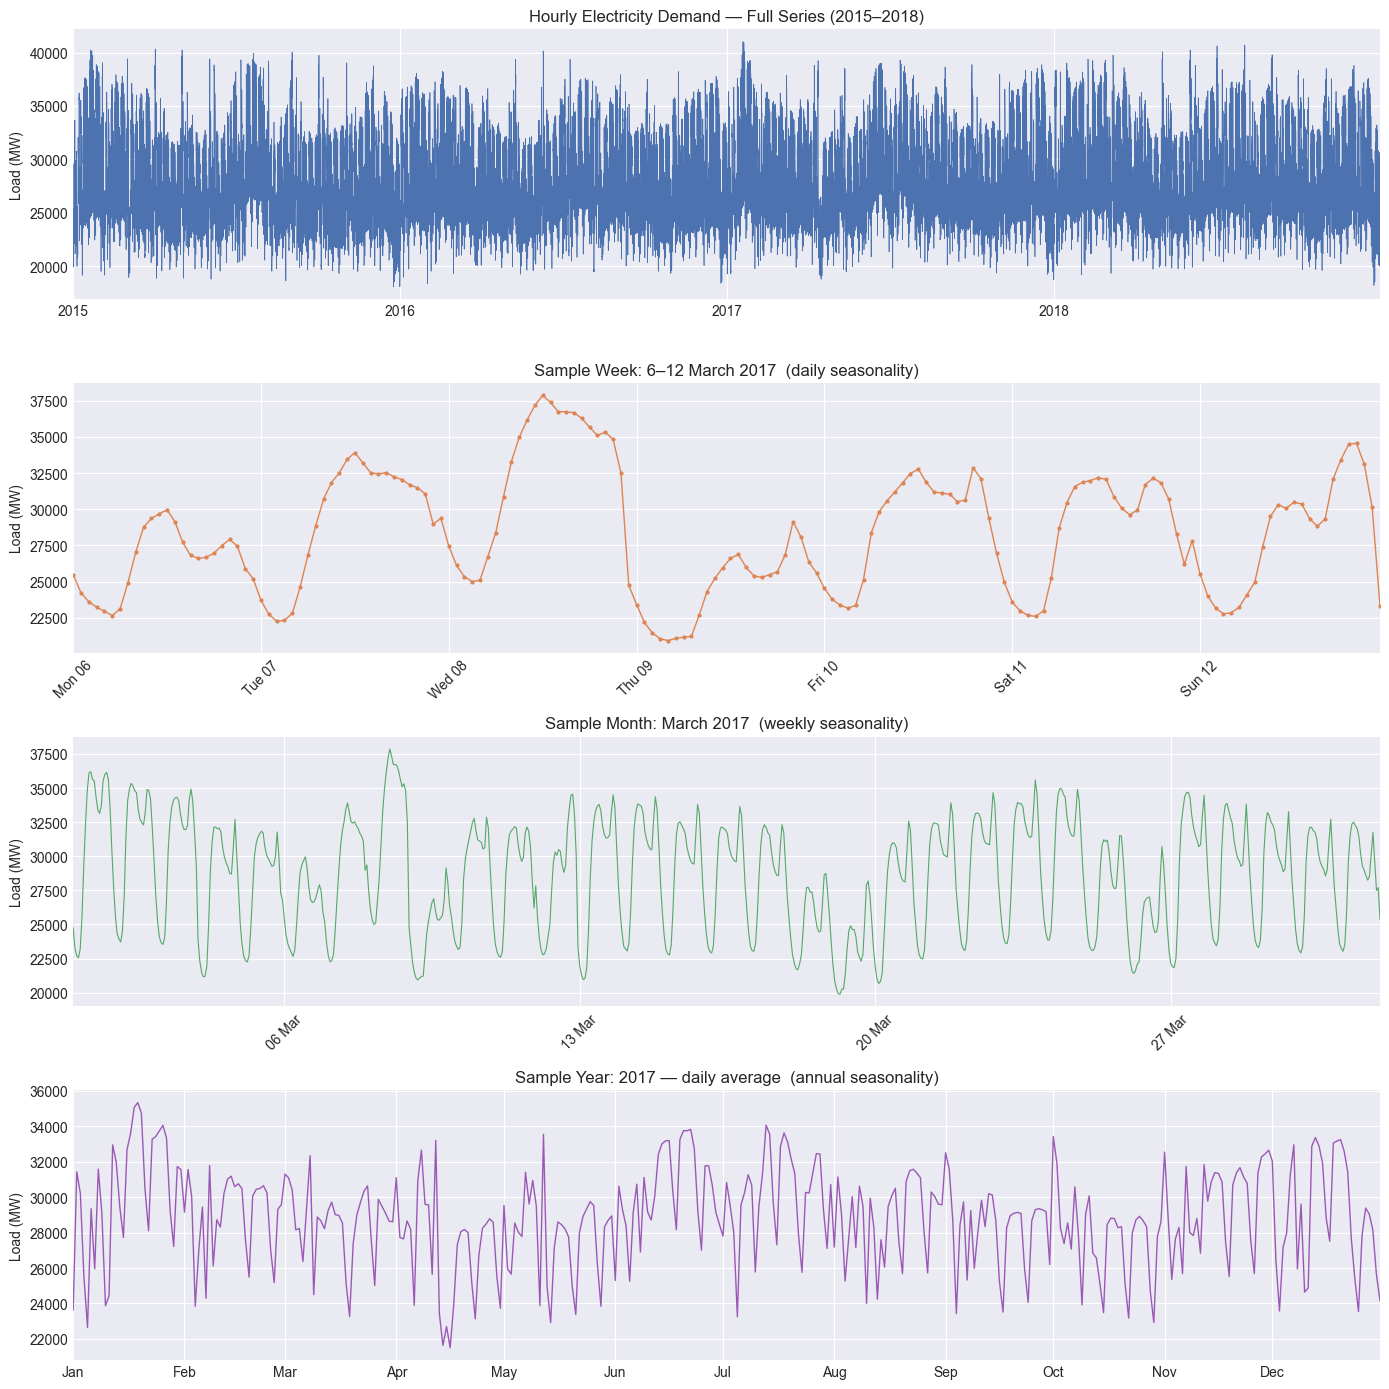

count    35064.0
mean     28698.0
std       4576.0
min      18041.0
25%      24807.0
50%      28902.0
75%      32193.0
max      41015.0
Name: total load actual, dtype: float64


In [34]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# Full series
df["total load actual"].plot(ax=axes[0], linewidth=0.5, color="#4c72b0")
axes[0].set_title("Hourly Electricity Demand — Full Series (2015–2018)", fontsize=12)
axes[0].set_ylabel("Load (MW)")
axes[0].set_xlabel("")

# Sample week — daily seasonality; one tick per day
week = df.loc["2017-03-06":"2017-03-12", "total load actual"]
axes[1].plot(week.index, week.values, marker="o", markersize=2, linewidth=1, color="#dd8452")
axes[1].set_title("Sample Week: 6–12 March 2017  (daily seasonality)", fontsize=12)
axes[1].set_ylabel("Load (MW)")
axes[1].set_xlim(week.index[0], week.index[-1])
week_ticks = pd.date_range("2017-03-06", "2017-03-12", freq="D")
axes[1].set_xticks(week_ticks)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
axes[1].tick_params(axis="x", rotation=45)

# Sample month — weekly seasonality; one tick per Monday (start of each week)
month = df.loc["2017-03-01":"2017-03-31", "total load actual"]
axes[2].plot(month.index, month.values, linewidth=0.8, color="#55a868")
axes[2].set_title("Sample Month: March 2017  (weekly seasonality)", fontsize=12)
axes[2].set_ylabel("Load (MW)")
axes[2].set_xlim(month.index[0], month.index[-1])
month_ticks = pd.date_range("2017-03-01", "2017-03-31", freq="W-MON")
axes[2].set_xticks(month_ticks)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axes[2].tick_params(axis="x", rotation=45)

# Sample year — annual seasonality
year = df.loc["2017-01-01":"2017-12-31", "total load actual"].resample("D").mean()
axes[3].plot(year.index, year.values, linewidth=1, color="#9b59b6")
axes[3].set_title("Sample Year: 2017 — daily average  (annual seasonality)", fontsize=12)
axes[3].set_ylabel("Load (MW)")
axes[3].set_xlim(year.index[0], year.index[-1])
axes[3].xaxis.set_major_locator(mdates.MonthLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

print(df["total load actual"].describe().round(0))


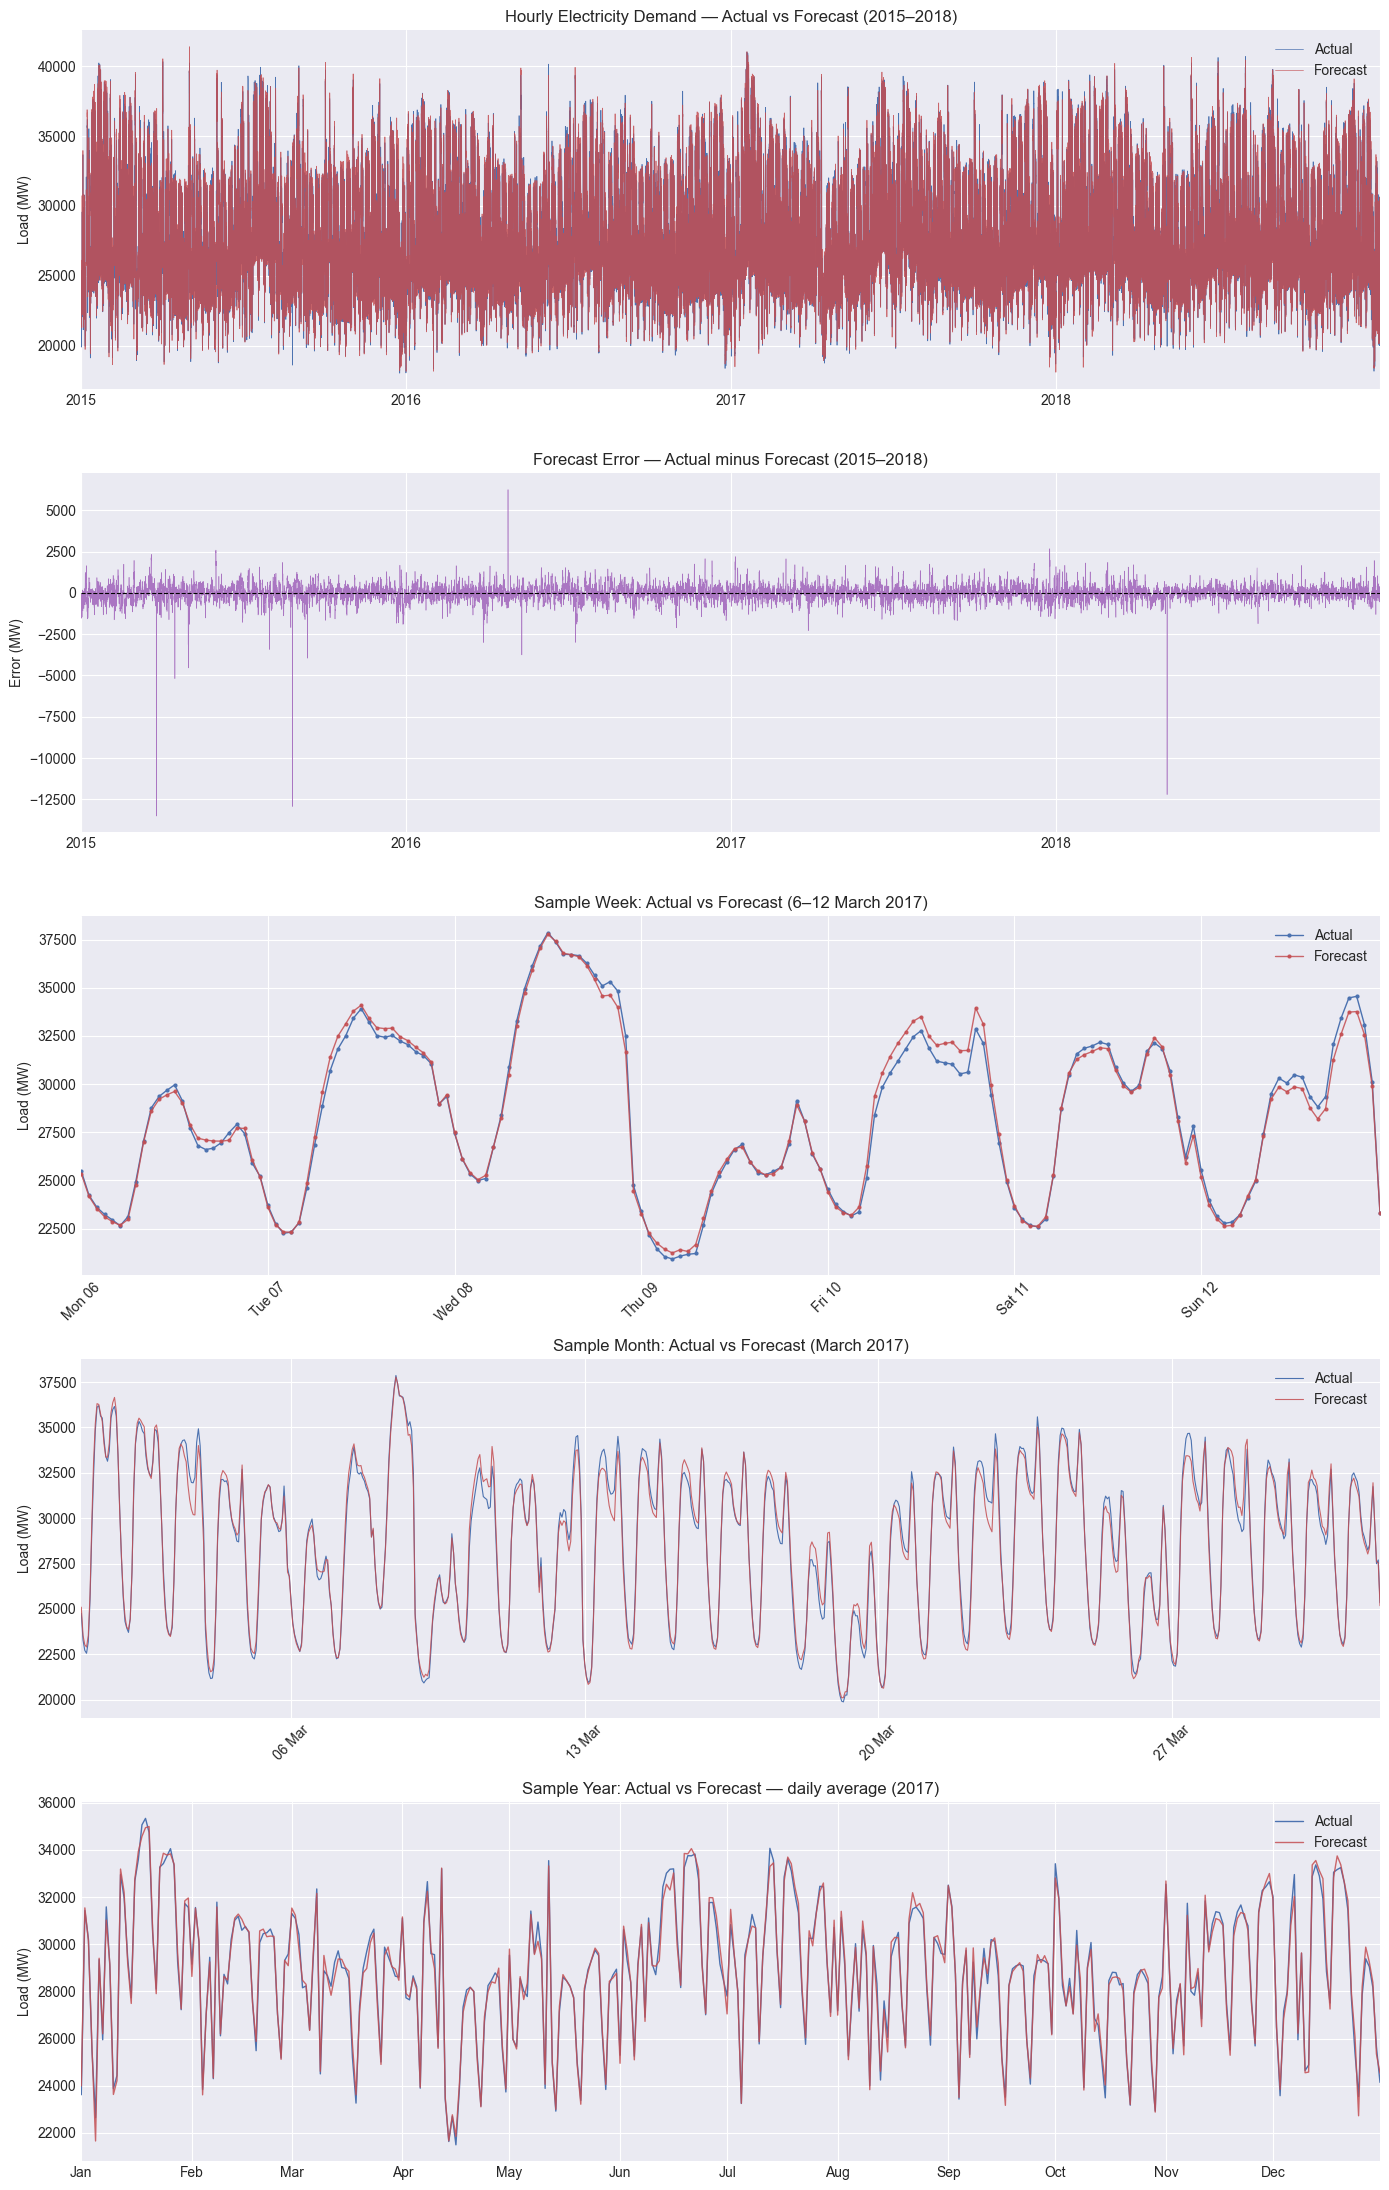

       total load actual  total load forecast
count            35064.0              35064.0
mean             28698.0              28712.0
std               4576.0               4594.0
min              18041.0              18105.0
25%              24807.0              24794.0
50%              28902.0              28906.0
75%              32193.0              32263.0
max              41015.0              41390.0

Forecast error  mean=-14 MW  std=452 MW  MAE=316 MW


In [37]:
fig, axes = plt.subplots(5, 1, figsize=(14, 22))

# Full series: actual vs forecast
df["total load actual"].plot(ax=axes[0], linewidth=0.5, color="#4c72b0", label="Actual")
df["total load forecast"].plot(ax=axes[0], linewidth=0.5, color="#c44e52", alpha=0.85, label="Forecast")
axes[0].set_title("Hourly Electricity Demand — Actual vs Forecast (2015–2018)", fontsize=12)
axes[0].set_ylabel("Load (MW)")
axes[0].set_xlabel("")
axes[0].legend(loc="upper right")

# Full series: forecast error (actual − forecast)
error = df["total load actual"] - df["total load forecast"]
error.plot(ax=axes[1], linewidth=0.4, color="#9b59b6", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Forecast Error — Actual minus Forecast (2015–2018)", fontsize=12)
axes[1].set_ylabel("Error (MW)")
axes[1].set_xlabel("")

# Sample week: actual vs forecast
week_cmp = df.loc["2017-03-06":"2017-03-12", ["total load actual", "total load forecast"]]
axes[2].plot(week_cmp.index, week_cmp["total load actual"].values,
             marker="o", markersize=2, linewidth=1, color="#4c72b0", label="Actual")
axes[2].plot(week_cmp.index, week_cmp["total load forecast"].values,
             marker="o", markersize=2, linewidth=1, color="#c44e52", alpha=0.85, label="Forecast")
axes[2].set_title("Sample Week: Actual vs Forecast (6–12 March 2017)", fontsize=12)
axes[2].set_ylabel("Load (MW)")
axes[2].set_xlim(week_cmp.index[0], week_cmp.index[-1])
week_ticks = pd.date_range("2017-03-06", "2017-03-12", freq="D")
axes[2].set_xticks(week_ticks)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(loc="upper right")

# Sample month: actual vs forecast
month_cmp = df.loc["2017-03-01":"2017-03-31", ["total load actual", "total load forecast"]]
axes[3].plot(month_cmp.index, month_cmp["total load actual"].values,
             linewidth=0.8, color="#4c72b0", label="Actual")
axes[3].plot(month_cmp.index, month_cmp["total load forecast"].values,
             linewidth=0.8, color="#c44e52", alpha=0.85, label="Forecast")
axes[3].set_title("Sample Month: Actual vs Forecast (March 2017)", fontsize=12)
axes[3].set_ylabel("Load (MW)")
axes[3].set_xlim(month_cmp.index[0], month_cmp.index[-1])
month_ticks = pd.date_range("2017-03-01", "2017-03-31", freq="W-MON")
axes[3].set_xticks(month_ticks)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axes[3].tick_params(axis="x", rotation=45)
axes[3].legend(loc="upper right")

# Sample year: actual vs forecast (daily average)
year_actual   = df.loc["2017-01-01":"2017-12-31", "total load actual"].resample("D").mean()
year_forecast = df.loc["2017-01-01":"2017-12-31", "total load forecast"].resample("D").mean()
axes[4].plot(year_actual.index, year_actual.values, linewidth=1, color="#4c72b0", label="Actual")
axes[4].plot(year_forecast.index, year_forecast.values, linewidth=1, color="#c44e52", alpha=0.85, label="Forecast")
axes[4].set_title("Sample Year: Actual vs Forecast — daily average (2017)", fontsize=12)
axes[4].set_ylabel("Load (MW)")
axes[4].set_xlim(year_actual.index[0], year_actual.index[-1])
axes[4].xaxis.set_major_locator(mdates.MonthLocator())
axes[4].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[4].legend(loc="upper right")

plt.tight_layout()
plt.show()

print(df[["total load actual", "total load forecast"]].describe().round(0))
print(f"\nForecast error  mean={error.mean():.0f} MW  std={error.std():.0f} MW  MAE={error.abs().mean():.0f} MW")


## 5. Seasonal Patterns

Electricity demand exhibits **multi-scale seasonality**: intra-day, intra-week, and intra-year cycles all co-exist. Identifying these cycles is essential before selecting a forecasting model.

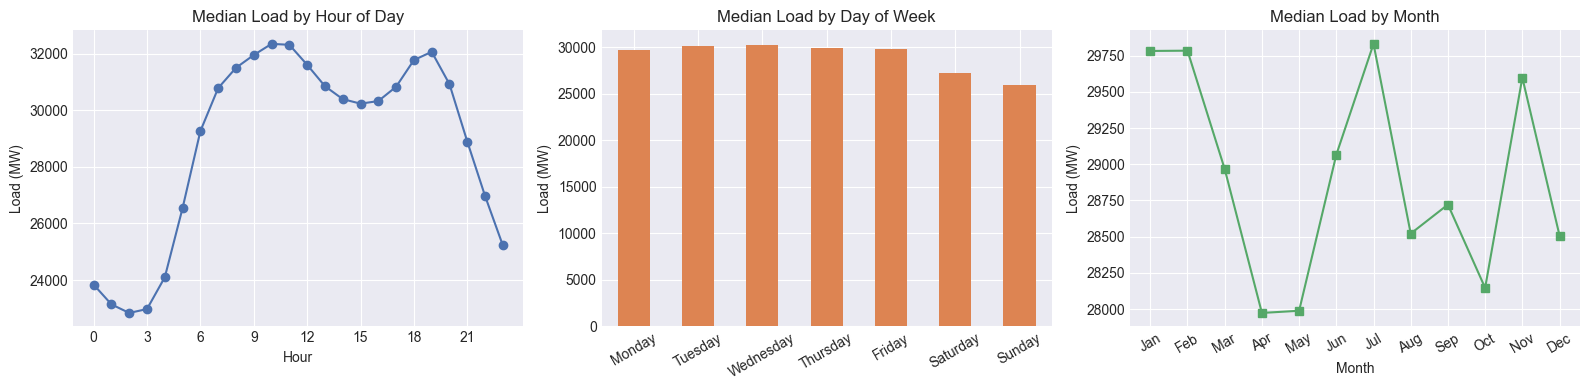

In [ ]:
# Calendar features
df["hour"]      = df.index.hour
df["weekday"]   = df.index.day_of_week        # 0=Mon … 6=Sun
df["month"]     = df.index.month
df["year"]      = df.index.year
df["week_name"] = df.index.day_name()

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
day_order    = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Hour of day
df.groupby("hour")["total load actual"].median().plot(
    ax=axes[0], marker="o", linewidth=1.5, color="#4c72b0")
axes[0].set_title("Median Load by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Load (MW)")
axes[0].set_xticks(range(0, 24, 3))

# Day of week
df.groupby("week_name")["total load actual"].median().reindex(day_order).plot(
    ax=axes[1], kind="bar", color="#dd8452", edgecolor="none")
axes[1].set_title("Median Load by Day of Week")
axes[1].set_xlabel("")
axes[1].set_ylabel("Load (MW)")
axes[1].tick_params(axis="x", rotation=30)

# Month of year
df.groupby("month")["total load actual"].median().plot(
    ax=axes[2], marker="s", linewidth=1.5, color="#55a868")
axes[2].set_title("Median Load by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Load (MW)")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_labels, rotation=30)

plt.tight_layout()
plt.show()

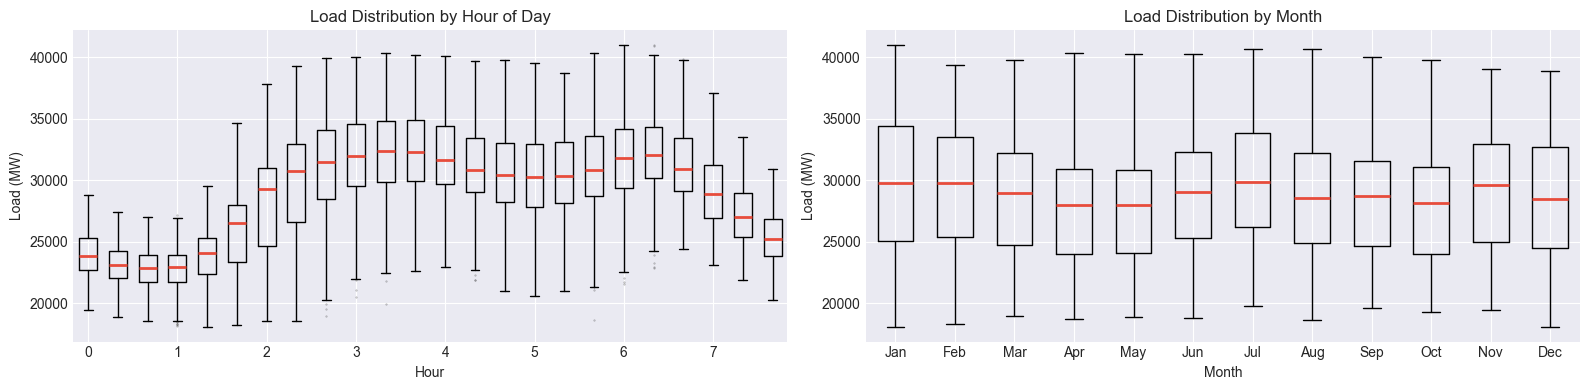

In [9]:
# Box plots — show full distribution including variability and outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

hour_data = [df[df["hour"] == h]["total load actual"].values for h in range(24)]
axes[0].boxplot(hour_data, positions=range(24), widths=0.6,
                medianprops=dict(color="#e74c3c", linewidth=2),
                flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[0].set_title("Load Distribution by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Load (MW)")
axes[0].set_xticks(range(0, 24, 3))

month_data = [df[df["month"] == m]["total load actual"].values for m in range(1, 13)]
axes[1].boxplot(month_data, positions=range(1, 13), widths=0.6,
                medianprops=dict(color="#e74c3c", linewidth=2),
                flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[1].set_title("Load Distribution by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Load (MW)")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)

plt.tight_layout()
plt.show()

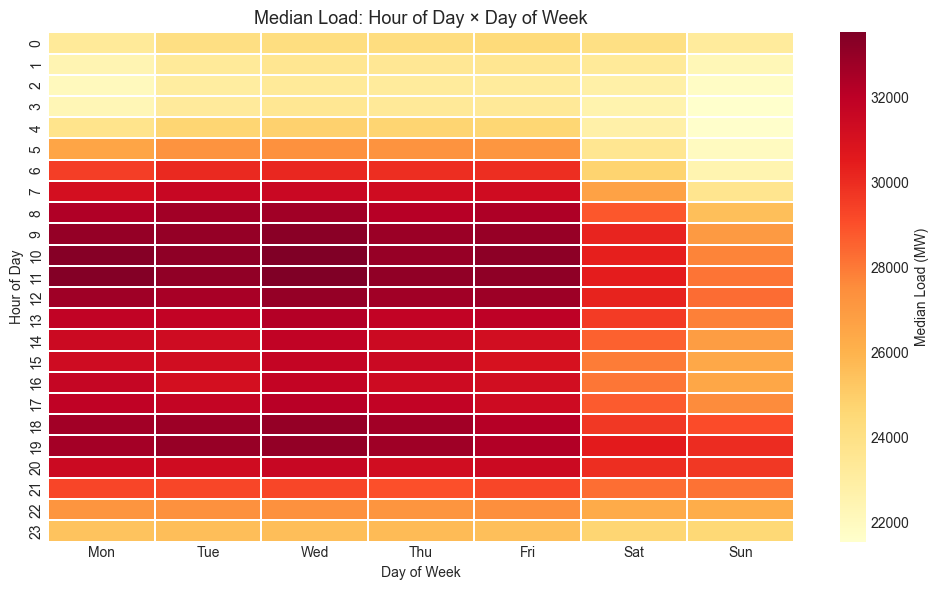

In [10]:
# Heatmap: average load by hour × day-of-week
pivot_hd = df.pivot_table(values="total load actual", index="hour", columns="weekday", aggfunc="median")
pivot_hd.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_hd, cmap="YlOrRd", annot=False,
            linewidths=0.3, ax=ax, cbar_kws={"label": "Median Load (MW)"})
ax.set_title("Median Load: Hour of Day × Day of Week", fontsize=13)
ax.set_ylabel("Hour of Day")
ax.set_xlabel("Day of Week")
plt.tight_layout()
plt.show()

## 6. Generation Mix

Spain's grid draws from diverse sources. The breakdown below reveals the dominant contributors and shows how the renewable share evolved over the dataset period.

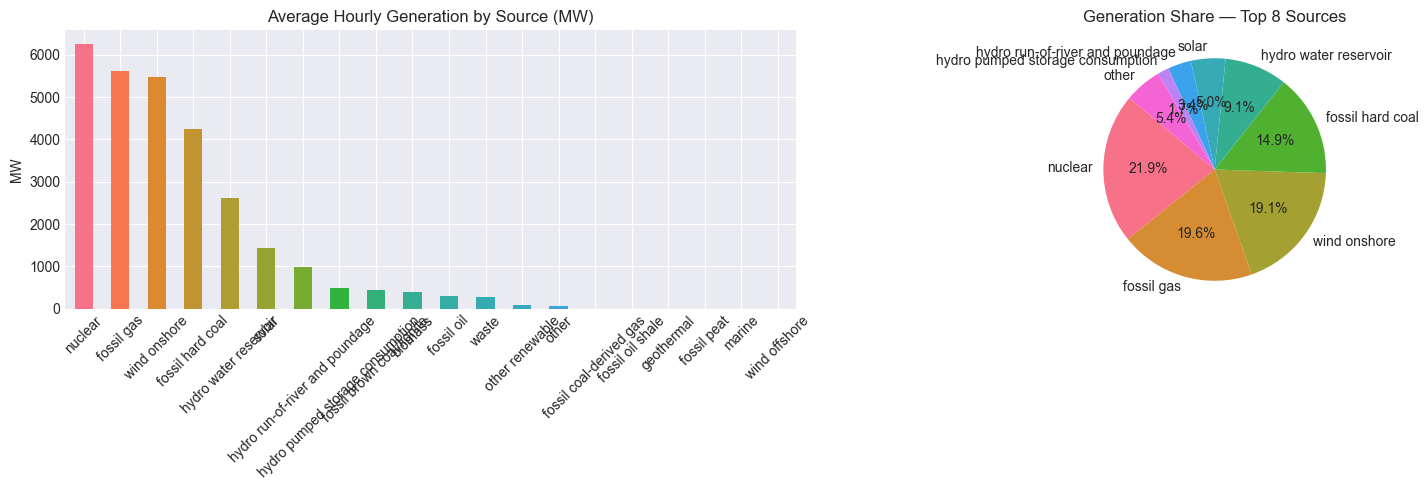

In [ ]:
gen_cols = [c for c in df.columns if c.startswith("generation") and "pumped storage aggregated" not in c]

gen_means = df[gen_cols].mean().sort_values(ascending=False)
gen_means.index = [c.replace("generation ", "") for c in gen_means.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of average hourly MW per source
gen_means.plot(kind="bar", ax=axes[0], edgecolor="none",
               color=sns.color_palette("husl", len(gen_means)))
axes[0].set_title("Average Hourly Generation by Source (MW)")
axes[0].set_ylabel("MW")
axes[0].tick_params(axis="x", rotation=45)

# Pie chart — top 8 sources
top_n = 8
top   = gen_means.nlargest(top_n)
other = gen_means[~gen_means.index.isin(top.index)].sum()
pie_data = pd.concat([top, pd.Series({"other": other})])
axes[1].pie(pie_data, labels=pie_data.index, autopct="%1.1f%%",
            startangle=140, colors=sns.color_palette("husl", len(pie_data)))
axes[1].set_title(f"Generation Share — Top {top_n} Sources")

plt.tight_layout()
plt.show()

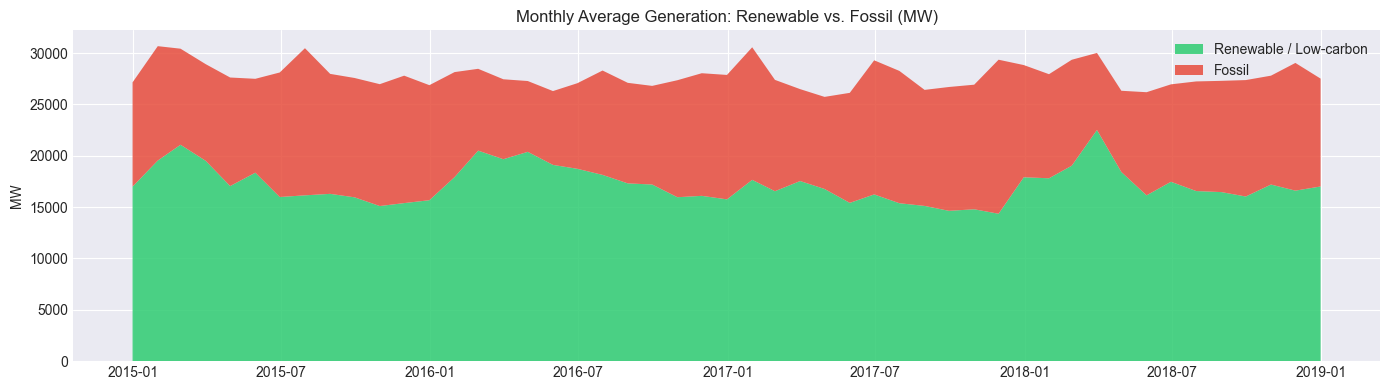

In [12]:
# Renewable vs. Fossil evolution (monthly average)
renewable_keywords = ["biomass","geothermal","hydro run","hydro water","marine",
                      "nuclear","solar","wind offshore","wind onshore","other renewable"]
fossil_keywords    = ["fossil","coal-derived","oil shale","peat"]

renewable_cols = [c for c in gen_cols if any(kw in c for kw in renewable_keywords)]
fossil_cols    = [c for c in gen_cols if any(kw in c for kw in fossil_keywords)]

monthly = df[renewable_cols + fossil_cols].resample("ME").mean()
monthly["Renewable"] = monthly[renewable_cols].sum(axis=1)
monthly["Fossil"]    = monthly[fossil_cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.stackplot(monthly.index,
             monthly["Renewable"], monthly["Fossil"],
             labels=["Renewable / Low-carbon", "Fossil"],
             colors=["#2ecc71", "#e74c3c"], alpha=0.85)
ax.set_title("Monthly Average Generation: Renewable vs. Fossil (MW)", fontsize=12)
ax.set_ylabel("MW")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 7. Price Analysis

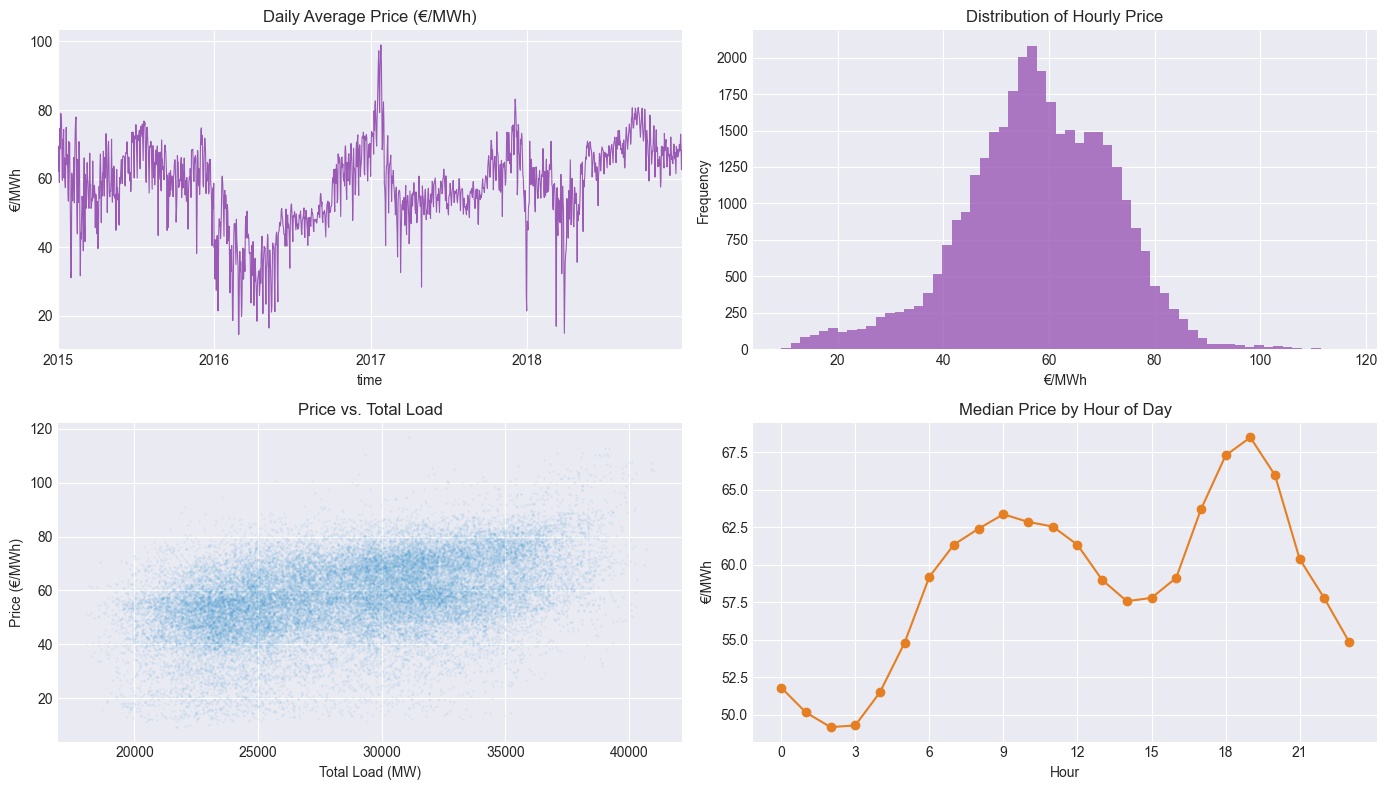

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Daily average price time series
df["price actual"].resample("D").mean().plot(ax=axes[0, 0], linewidth=0.8, color="#9b59b6")
axes[0, 0].set_title("Daily Average Price (€/MWh)")
axes[0, 0].set_ylabel("€/MWh")

# Distribution
df["price actual"].plot.hist(ax=axes[0, 1], bins=60, edgecolor="none", color="#9b59b6", alpha=0.8)
axes[0, 1].set_title("Distribution of Hourly Price")
axes[0, 1].set_xlabel("€/MWh")

# Price vs Load scatter
axes[1, 0].scatter(df["total load actual"], df["price actual"], alpha=0.05, s=1, color="#3498db")
axes[1, 0].set_xlabel("Total Load (MW)")
axes[1, 0].set_ylabel("Price (€/MWh)")
axes[1, 0].set_title("Price vs. Total Load")

# Price by hour of day
df.groupby("hour")["price actual"].median().plot(
    ax=axes[1, 1], marker="o", linewidth=1.5, color="#e67e22")
axes[1, 1].set_title("Median Price by Hour of Day")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].set_ylabel("€/MWh")
axes[1, 1].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

## 8. Weather Features

Five Spanish cities are covered: **Valencia, Madrid, Bilbao, Barcelona, Seville**. We compute a city-averaged signal per timestamp and join it with the energy data.

In [14]:
# City-average weather per timestamp
weather_avg = (
    weather.groupby("dt_iso")[["temp","humidity","wind_speed","pressure","clouds_all","rain_1h"]]
    .mean()
    .rename_axis("time")
)
df_merged = df.join(weather_avg, how="left")
df_merged["temp_c"] = df_merged["temp"] - 273.15   # Kelvin → Celsius
print(f"Merged shape: {df_merged.shape}")
df_merged[["temp_c","humidity","wind_speed","total load actual"]].describe().round(2)

Merged shape: (35064, 40)


,temp_c,humidity,wind_speed,total load actual
count,35064.00,35064.00,35064.00,35064.00
mean,16.53,68.22,2.47,28698.28
std,7.26,14.89,1.36,4575.83
min,-1.21,22.60,0.00,18041.00
25%,10.91,56.80,1.40,24807.00
50%,15.88,69.80,2.20,28902.00
75%,21.94,80.20,3.20,32194.25
max,36.12,100.00,29.80,41015.00


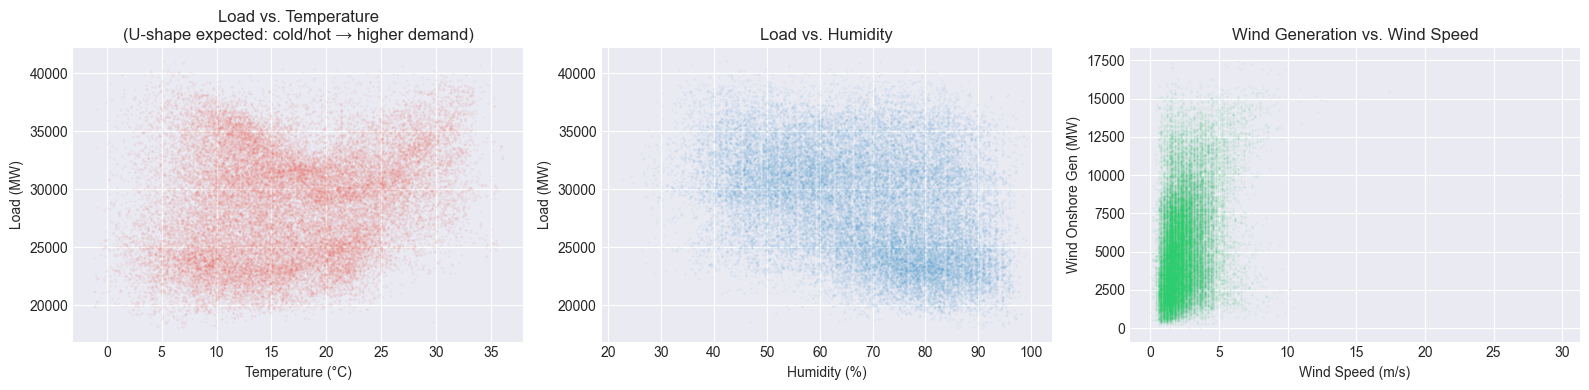

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df_merged["temp_c"], df_merged["total load actual"], alpha=0.04, s=1, color="#e74c3c")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Load (MW)")
axes[0].set_title("Load vs. Temperature\n(U-shape expected: cold/hot → higher demand)")

axes[1].scatter(df_merged["humidity"], df_merged["total load actual"], alpha=0.04, s=1, color="#3498db")
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("Load (MW)")
axes[1].set_title("Load vs. Humidity")

axes[2].scatter(df_merged["wind_speed"], df_merged["generation wind onshore"],
                alpha=0.04, s=1, color="#2ecc71")
axes[2].set_xlabel("Wind Speed (m/s)")
axes[2].set_ylabel("Wind Onshore Gen (MW)")
axes[2].set_title("Wind Generation vs. Wind Speed")

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

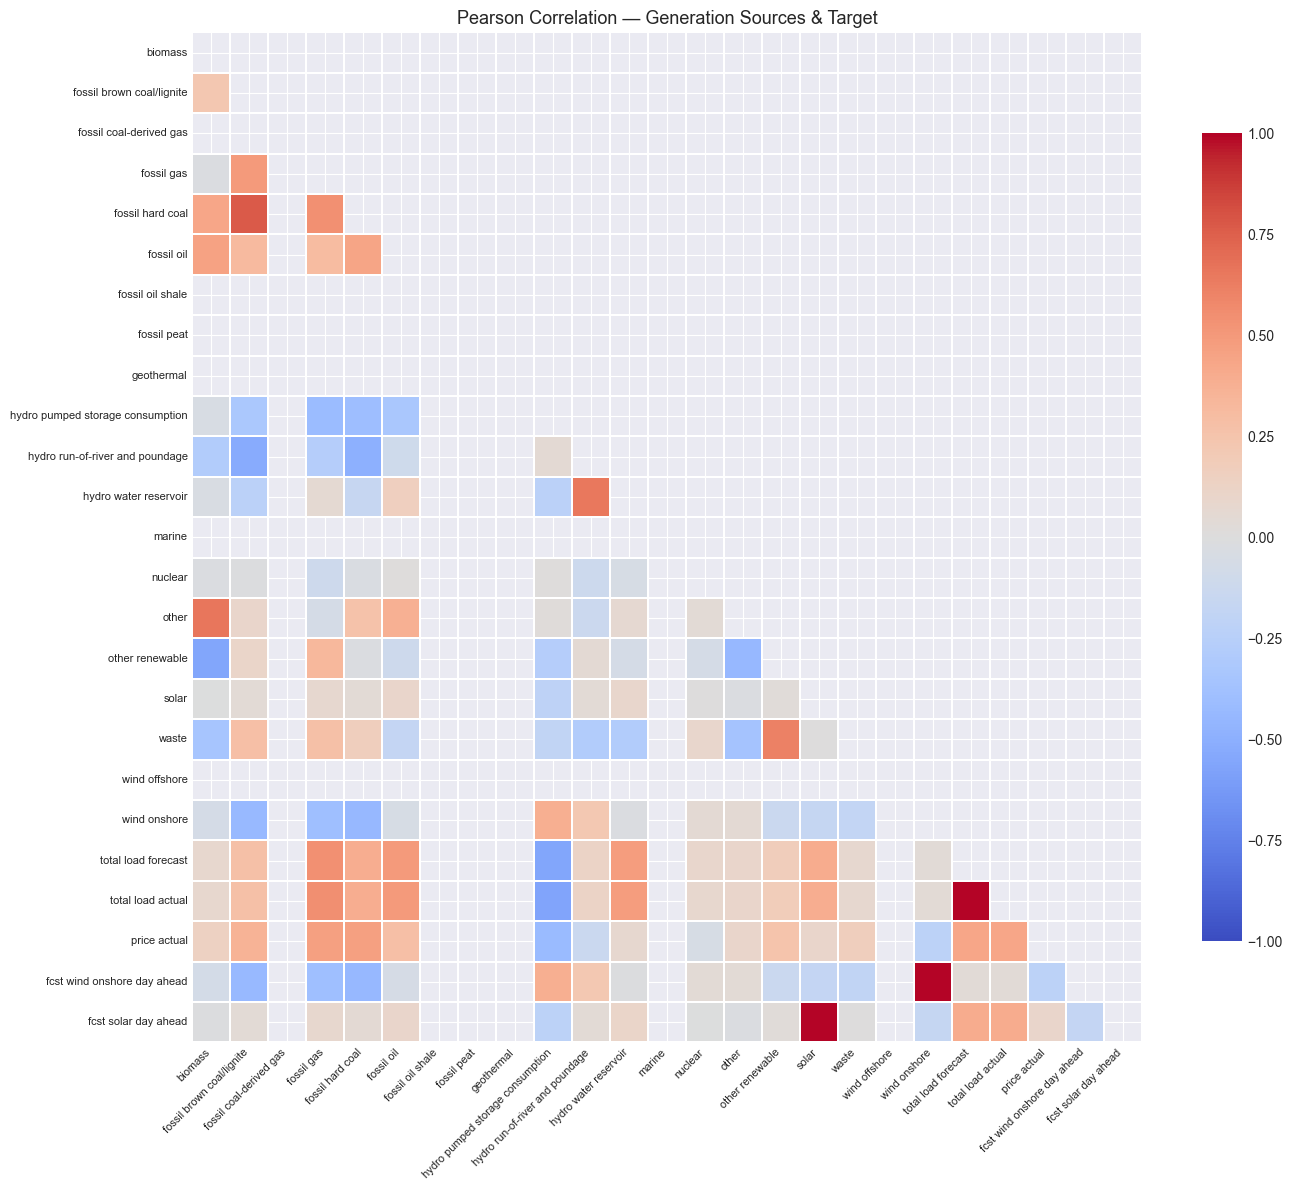

In [16]:
corr_cols = gen_cols + ["total load forecast", "total load actual", "price actual",
                        "forecast wind onshore day ahead", "forecast solar day ahead"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3,
            ax=ax, cbar_kws={"shrink": 0.8})
labels = [c.replace("generation ", "").replace("forecast ", "fcst ") for c in corr_cols]
ax.set_title("Pearson Correlation — Generation Sources & Target", fontsize=13)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
# Top correlates with total load actual
target_corr = corr_matrix["total load actual"].drop("total load actual").sort_values(key=abs, ascending=False)
print("Top correlates with total load actual:")
print(target_corr.head(12).round(3).to_string())

Top correlates with total load actual:
total load forecast                            0.995
generation hydro pumped storage consumption   -0.563
generation fossil gas                          0.549
generation fossil oil                          0.496
generation hydro water reservoir               0.479
price actual                                   0.435
forecast solar day ahead                       0.404
generation fossil hard coal                    0.397
generation solar                               0.396
generation fossil brown coal/lignite           0.280
generation other renewable                     0.181
generation hydro run-of-river and poundage     0.118


## 10. Time Series Decomposition

Classical additive decomposition separates the signal into **trend**, **seasonal**, and **residual** components. We apply it to a weekly-resampled series (period = 52 weeks) to expose the yearly seasonality cleanly.

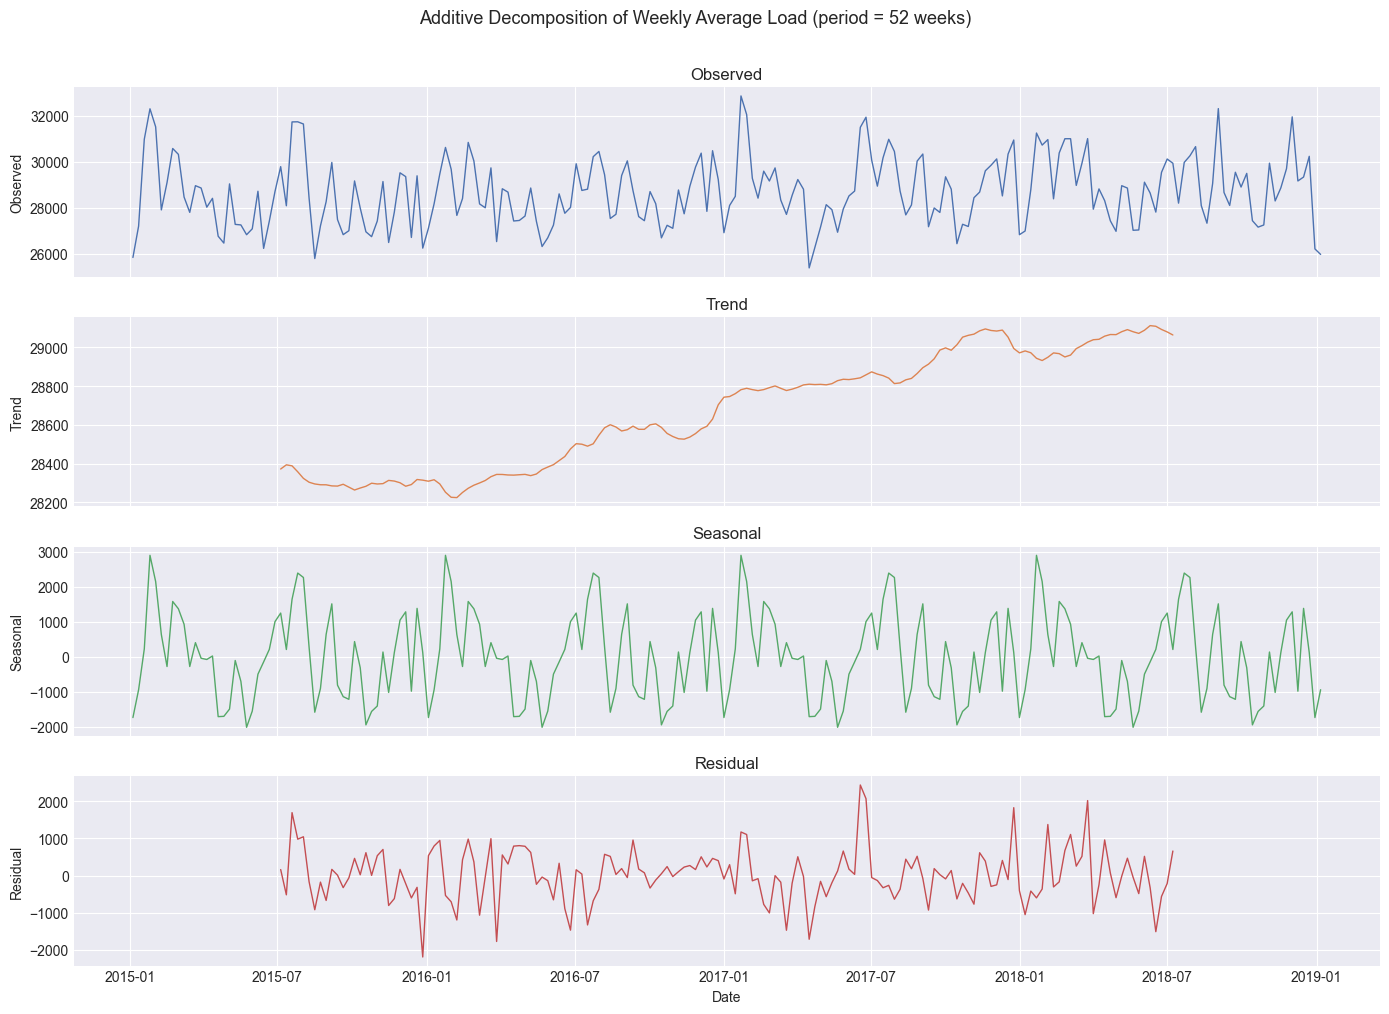

In [18]:
weekly_load = df["total load actual"].resample("W").mean()

decomp = seasonal_decompose(weekly_load, model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    (weekly_load,     "Observed",  "#4c72b0"),
    (decomp.trend,    "Trend",     "#dd8452"),
    (decomp.seasonal, "Seasonal",  "#55a868"),
    (decomp.resid,    "Residual",  "#c44e52"),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1)
    ax.set_ylabel(title)
    ax.set_title(title)

axes[-1].set_xlabel("Date")
fig.suptitle("Additive Decomposition of Weekly Average Load (period = 52 weeks)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 11. ACF / PACF Analysis

ACF and PACF plots of the **daily average** load help identify autocorrelation structure and suitable lag orders for statistical models (e.g., SARIMA).

As covered in the course material, we use **both ADF and KPSS** tests together for a confirmatory stationarity assessment:

| ADF rejects H₀ | KPSS fails to reject H₀ | Conclusion |
|---|---|---|
| ✓ | ✓ | **Strong evidence of stationarity** |
| ✗ | ✗ | **Strong evidence of non-stationarity** |
| conflicting | — | Inspect visually; consider differencing |

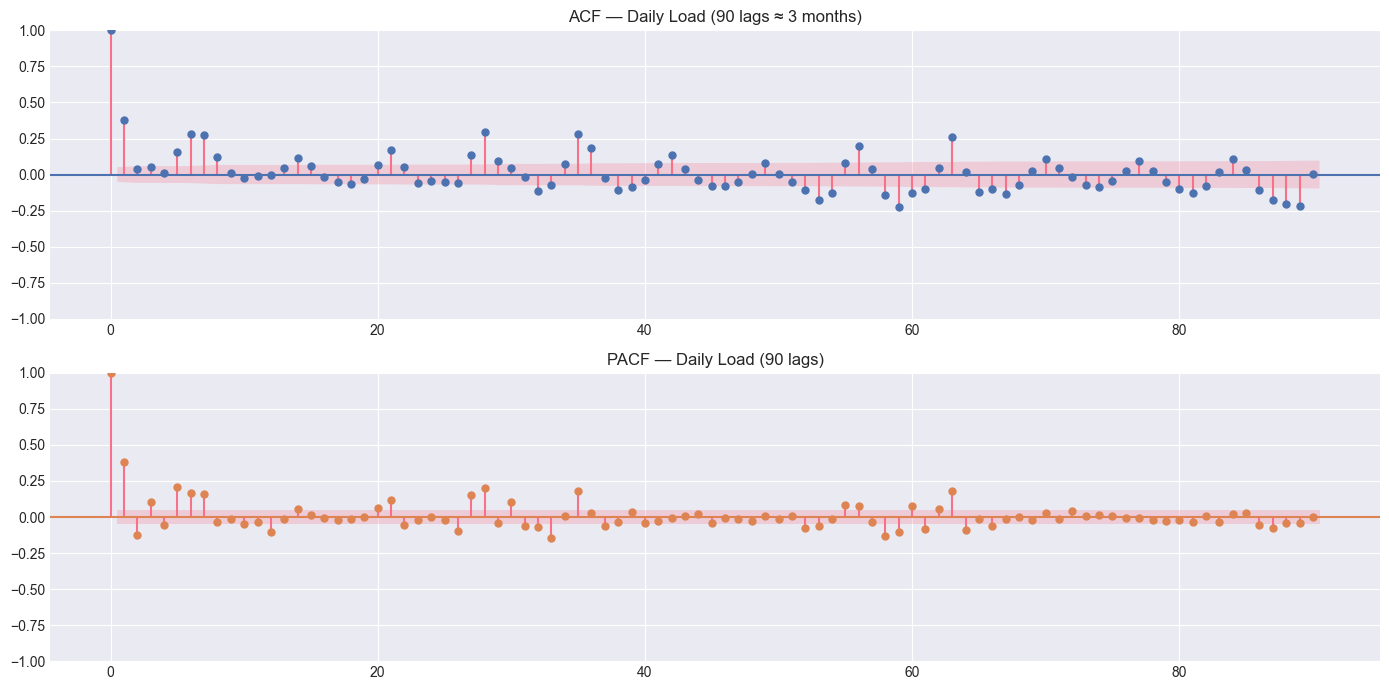

In [ ]:
daily_load = df["total load actual"].resample("D").mean().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(daily_load, lags=90, ax=axes[0], alpha=0.05, color="#4c72b0")
axes[0].set_title("ACF — Daily Load (90 lags ≈ 3 months)")

plot_pacf(daily_load, lags=90, ax=axes[1], alpha=0.05, method="ywm", color="#dd8452")
axes[1].set_title("PACF — Daily Load (90 lags)")

plt.tight_layout()
plt.show()

In [20]:
adf_result  = adfuller(daily_load, autolag="AIC")
kpss_result = kpss(daily_load, regression="c", nlags="auto")

print("=" * 55)
print("ADF Test  (H₀: unit root — non-stationary)")
print("=" * 55)
print(f"  Test statistic : {adf_result[0]:.4f}")
print(f"  p-value        : {adf_result[1]:.4f}")
print(f"  Lags used      : {adf_result[2]}")
adf_conclusion = "STATIONARY (reject H₀)" if adf_result[1] < 0.05 else "NON-STATIONARY (fail to reject H₀)"
print(f"  → {adf_conclusion}")

print()
print("=" * 55)
print("KPSS Test (H₀: stationary)")
print("=" * 55)
print(f"  Test statistic : {kpss_result[0]:.4f}")
print(f"  p-value        : {kpss_result[1]:.4f}")
print(f"  Lags used      : {kpss_result[2]}")
kpss_conclusion = "STATIONARY (fail to reject H₀)" if kpss_result[1] >= 0.05 else "NON-STATIONARY (reject H₀)"
print(f"  → {kpss_conclusion}")

ADF Test  (H₀: unit root — non-stationary)
  Test statistic : -6.4635
  p-value        : 0.0000
  Lags used      : 21
  → STATIONARY (reject H₀)

KPSS Test (H₀: stationary)
  Test statistic : 0.4452
  p-value        : 0.0577
  Lags used      : 15
  → STATIONARY (fail to reject H₀)


---

## Summary of Key Findings

| Finding | Detail |
|---|---|
| **Time range** | Hourly, 2015-01-01 → 2018-12-31 (~35 k observations) |
| **Missing values** | Several generation columns partially missing; target gap-filled by interpolation |
| **Intra-day pattern** | Clear double-peak (morning ~9h, evening ~20h); trough at night |
| **Weekly pattern** | Weekdays carry ~15–20% higher load than weekends |
| **Annual pattern** | Winter & autumn peaks; summer trough in demand |
| **Dominant sources** | Nuclear, wind onshore, gas, and hydro reservoir lead generation |
| **Renewable trend** | Wind + solar + nuclear represent the majority of low-carbon generation |
| **Price–load link** | Moderate positive correlation; prices spike at peak-demand hours |
| **Stationarity** | Daily series appears stationary after visual inspection and formal tests |
| **ACF/PACF** | Strong autocorrelation at lag 7 (weekly) — key seasonal period for models |

**Next steps:** feature engineering (calendar dummies, lag features), model selection (SARIMA / ML / hybrid).